# DIABLO: gex-only, morph-only, joint

Compares three mixOmics DIABLO (`block.splsda`) embeddings of the 119 HepG2
drug pseudobulk profiles, computed in `wl_diablo_moa.Rmd` and exported to
`data/mixOmics/diablo_embeddings/`:

- **DIABLO (gex only)** — `block.splsda` fit on the gex block alone
- **DIABLO (morph only)** — `block.splsda` fit on the morph block alone
- **DIABLO (joint)** — the two-block model, reduced to one embedding per
  compound via the weighted average of its per-block components (weighted
  by each block's correlation with `moa-fine`, i.e. what
  `plotIndiv(diablo, blocks = "weighted.average")` plots)

All three share the same `ncomp` and the same per-block `keepX` as tuned for
the joint model, and are trained on the same 47 compounds (labelled with a
real, non-`"unclear"`, non-tiny `moa-fine` class) — so unlike the
`wl_integration_scvi.ipynb` comparison (different architectures, different
training objectives), differences between these three come only from
*which block(s) the model could see*, not from different methods.

This notebook applies the same metrics as scvi.

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors


## Load the DIABLO embeddings

Each CSV has one row per compound (`compound`, `moa_fine`, `source`
["training" or "projected"], `comp1..compN`). `source` distinguishes the 47
compounds DIABLO was actually trained on from the 55 `"unclear"` compounds
that were excluded from training and only `predict()`-projected into the
fitted space afterwards (see `wl_diablo_moa.Rmd` sections 3 and 12-13).

In [16]:
EMBED_DIR = "data/mixOmics/diablo_embeddings"

embedding_files = {
    "DIABLO (gex only)": "diablo_gex.csv",
    "DIABLO (morph only)": "diablo_morph.csv",
    "DIABLO (joint)": "diablo_joint.csv",
}

embed_dfs = {name: pd.read_csv(f"{EMBED_DIR}/{fname}").set_index("compound")
             for name, fname in embedding_files.items()}

# obs (moa_fine, source) should line up across all three -- sanity check
ref = embed_dfs["DIABLO (joint)"][["moa_fine", "source"]]
for name, df in embed_dfs.items():
    assert df.index.equals(ref.index), f"{name}: compound order differs from the joint embedding"
    assert (df["moa_fine"] == ref["moa_fine"]).all(), f"{name}: moa_fine labels differ"

obs = ref.rename(columns={"moa_fine": "moa-fine"}).copy()
obs["moa-fine"] = obs["moa-fine"].astype("category")
obs["source"] = obs["source"].astype("category")

adata = ad.AnnData(X=np.zeros((obs.shape[0], 1), dtype="float32"), obs=obs)
for name, df in embed_dfs.items():
    comp_cols = [c for c in df.columns if c.startswith("comp")]
    adata.obsm[name] = df.loc[adata.obs_names, comp_cols].to_numpy(dtype="float32")

adata

AnnData object with n_obs × n_vars = 102 × 1
    obs: 'moa-fine', 'source'
    obsm: 'DIABLO (gex only)', 'DIABLO (morph only)', 'DIABLO (joint)'
    layers: None (.X)

Reuse the same `moa-fine` -> color mapping as `wl_integration_scvi.ipynb`
(`data/mixOmics/moa_fine_colors.csv`), so a given MOA class is the same
colour in both notebooks' plots. This notebook's `adata` only has a subset
of the full category list (training excludes `"unclear"` and tiny classes,
though `"unclear"` itself still shows up via the projected points) --
`.loc[...]` on the shared mapping handles that subset fine.

In [ ]:
moa_fine_colors = pd.read_csv("data/mixOmics/moa_fine_colors.csv").set_index("moa_fine")["color"]
adata.uns["moa-fine_colors"] = moa_fine_colors.loc[adata.obs["moa-fine"].cat.categories].to_numpy()

## UMAP

In [18]:
embedding_keys = {name: name for name in embedding_files}  # obsm key == method name here
n_methods = len(embedding_keys)

for key in embedding_keys.values():
    sc.pp.neighbors(adata, use_rep=key, metric="cosine", key_added=key)
    sc.tl.umap(adata, neighbors_key=key, key_added=f"{key}_umap")


## Compare embeddings by `moa-fine`

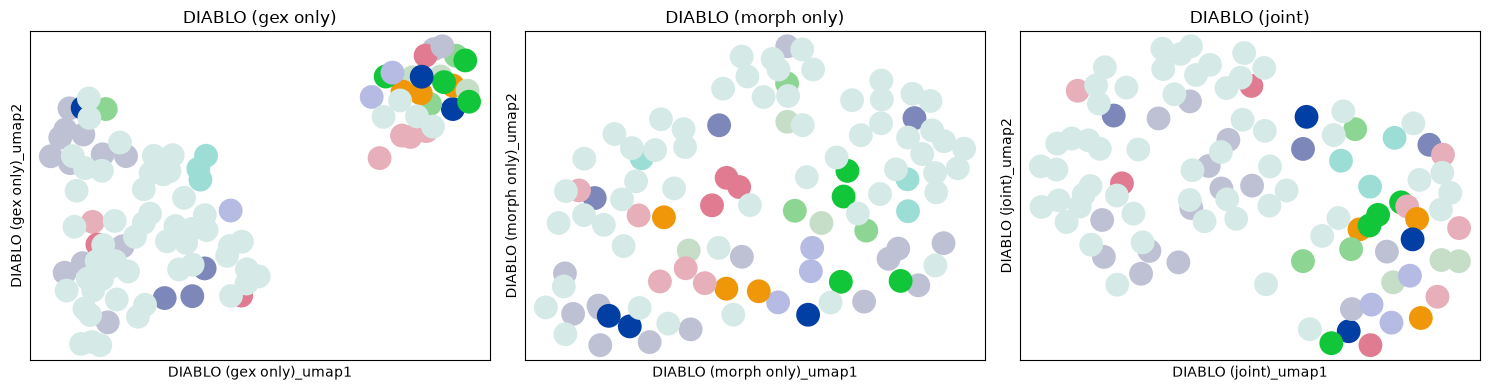

In [19]:
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 4), squeeze=False)

for ax, (method_name, key) in zip(axes.ravel(), embedding_keys.items()):
    sc.pl.embedding(
        adata,
        basis=f"{key}_umap",
        color="moa-fine",
        ax=ax,
        show=False,
        title=method_name,
        legend_loc=None,
        legend_fontsize=8,
    )

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.savefig("figures/umap_comparison_diablo.png", dpi=300)
plt.show()


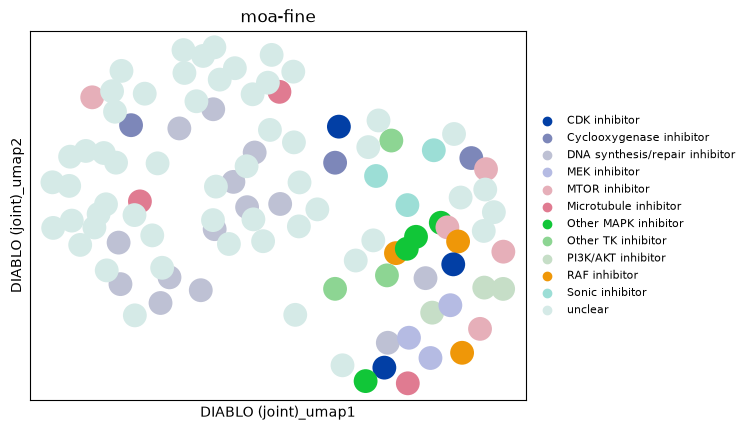

<Figure size 640x480 with 0 Axes>

In [24]:
sc.pl.embedding(
        adata,
        basis="DIABLO (joint)_umap",
        color="moa-fine",
        legend_loc="right margin",
        legend_fontsize=8,
        show=True
    )
plt.tight_layout()
plt.savefig("figures/umap_diablo.png", dpi=300)

Same layout, but marking which points DIABLO actually trained on vs.
`predict()`-projected after the fact (the `"unclear"` compounds).

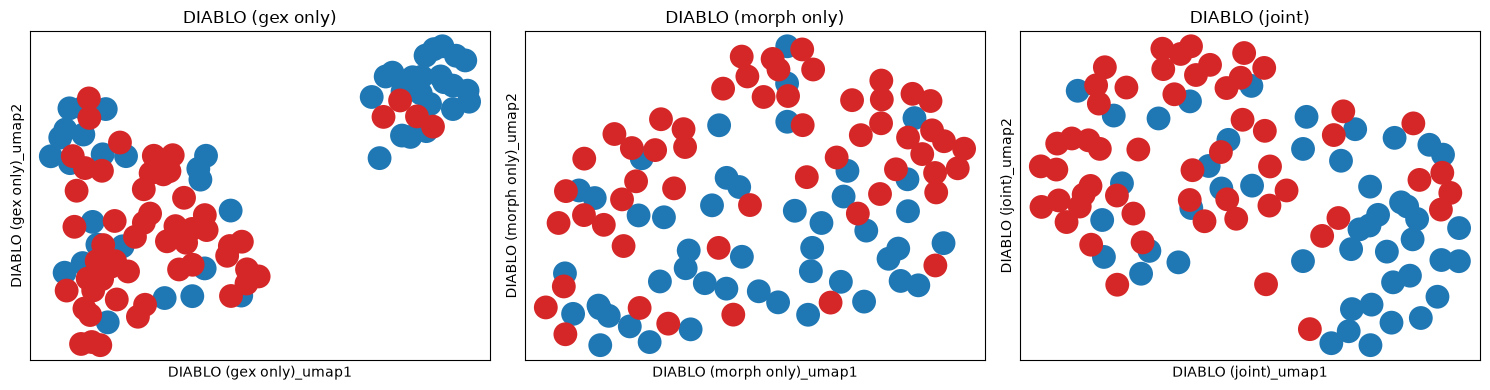

In [21]:
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 4), squeeze=False)

for ax, (method_name, key) in zip(axes.ravel(), embedding_keys.items()):
    sc.pl.embedding(
        adata,
        basis=f"{key}_umap",
        color="source",
        ax=ax,
        show=False,
        title=method_name,
        legend_loc=None,
        legend_fontsize=8,
        palette={"training": "#1f77b4", "projected": "#d62728"},
    )

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.savefig("figures/umap_comparison_diablo_source.png", dpi=300)
plt.show()


## Integration metrics: how well does each embedding recapitulate drug structure?

Same definitions as `wl_integration_scvi.ipynb`. Restricted to the
`"training"` compounds (i.e. `moa-fine != "unclear"`) — those are exactly
the 47 compounds DIABLO was fit on, across ~11 MOA categories with 3-14
members each.

Note the compound/class set here is smaller than in
`wl_integration_scvi.ipynb` (47 compounds / ~11 classes vs. 64 / 20 there,
since DIABLO also drops classes below `min_class_n`) — so treat cross-table
comparisons against the scVI numbers as indicative only; comparisons
*within* this table (gex-only vs. morph-only vs. joint) are apples-to-apples
since all three share the same compounds and classes.

- **Silhouette score** (`moa-fine` labels, embedding coordinates): how
  well-separated MOA groups are in the embedding. Ranges -1..1, higher is
  better.
- **kNN purity (k=5)**: for each drug, the fraction of its 5 nearest
  neighbors *in the embedding* sharing its MOA label.
- **Enrichment over chance**: kNN purity divided by the purity expected if
  neighbors were random; enrichment > 1 means better than chance.
- **ARI / NMI** (K-means, k = number of MOA categories, vs. true `moa-fine`
  labels): a coarser, cluster-level view of the same question.

In [22]:
known = adata.obs["source"] == "training"
labels_all = adata.obs["moa-fine"].astype(str).to_numpy(dtype=object)
print(f"{known.sum()} / {adata.n_obs} drugs have a known moa-fine label (i.e. were trained on)")


def knn_purity(X, labels, k=5):
    """Fraction of each point's k nearest neighbors sharing its label."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, idx = nn.kneighbors(X)
    idx = idx[:, 1:]  # drop self
    return (labels[idx] == labels[:, None]).mean(axis=1)


rows = []
for name, key in embedding_keys.items():
    Xk = adata.obsm[key][known.values]
    lk = labels_all[known.values]

    silhouette = silhouette_score(Xk, lk, metric="euclidean")

    purity_k5 = knn_purity(Xk, lk, k=5).mean()
    group_size = pd.Series(lk).map(pd.Series(lk).value_counts()).to_numpy()
    chance_k5 = ((group_size - 1) / (len(lk) - 1)).mean()

    kmeans = KMeans(n_clusters=pd.Series(lk).nunique(), n_init=10, random_state=0).fit(Xk)
    ari = adjusted_rand_score(lk, kmeans.labels_)
    nmi = normalized_mutual_info_score(lk, kmeans.labels_)

    rows.append(dict(
        embedding=name,
        silhouette_moa=silhouette,
        knn_purity_k5=purity_k5,
        chance_k5=chance_k5,
        enrichment_k5=purity_k5 / chance_k5,
        ari_kmeans=ari,
        nmi_kmeans=nmi,
    ))

metrics_df = pd.DataFrame(rows).set_index("embedding").round(3)
metrics_df.to_csv("figures/diablo_metrics.csv")
metrics_df

47 / 102 drugs have a known moa-fine label (i.e. were trained on)


,silhouette_moa,knn_purity_k5,chance_k5,enrichment_k5,ari_kmeans,nmi_kmeans
embedding,,,,,,
DIABLO (gex only),0.011,0.400,0.121,3.301,0.290,0.593
DIABLO (morph only),-0.097,0.306,0.121,2.528,0.120,0.551
DIABLO (joint),-0.215,0.289,0.121,2.388,0.044,0.416


Read the table as: **higher is better** on every column. If `DIABLO
(joint)` beats both single-block rows on `enrichment_k5` (and/or
`ari_kmeans` / `nmi_kmeans`), that's evidence the joint model is picking up
cross-modal MOA structure that neither block captures alone; if it lands
between the two single-block rows instead, the joint model may just be
dominated by whichever block has the stronger MOA signal on its own —
compare against `figures/scvi_metrics.csv` for the same question asked of
scVI/totalVI.